In [167]:
!git clone https://github.com/Iconic-Aman/Potato-Disease

fatal: destination path 'Potato-Disease' already exists and is not an empty directory.


In [168]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models,losses
import matplotlib.pyplot as plt
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential
from keras.callbacks import EarlyStopping, ModelCheckpoint
import numpy as np

In [169]:
IMAGE_SIZE = 256
BATCH_SIZE = 32
CHANNELS = 3
EPOCHS = 50

In [170]:
dataset = tf.keras.utils.image_dataset_from_directory(
    'Potato-Disease/villagepotato',
     shuffle=True,
     image_size=(IMAGE_SIZE, IMAGE_SIZE),
     batch_size= BATCH_SIZE
)

Found 2152 files belonging to 3 classes.


In [171]:
class_name = dataset.class_names
class_name

['Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy']

In [172]:
for image, label in dataset.take(1):
    print(label)
    print(label.numpy())
    print(image.shape)
    print(image[0].shape)

tf.Tensor([1 0 0 1 1 1 1 0 1 0 0 1 2 0 1 1 0 2 0 1 0 1 0 1 1 1 0 2 1 2 0 1], shape=(32,), dtype=int32)
[1 0 0 1 1 1 1 0 1 0 0 1 2 0 1 1 0 2 0 1 0 1 0 1 1 1 0 2 1 2 0 1]
(32, 256, 256, 3)
(256, 256, 3)


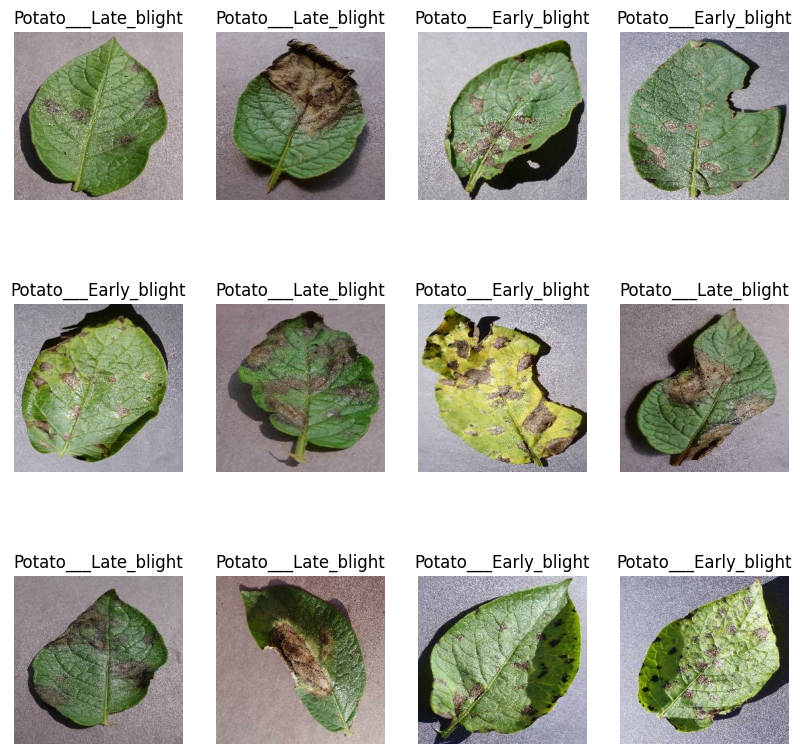

In [173]:
plt.figure(figsize=(10,10))
for image,label in dataset.take(1):
    for i in range(12):
        plt.subplot(3,4,i+1)
        plt.imshow(image[i].numpy().astype('uint8'))
        plt.axis('off')
        plt.title(class_name[label[i].numpy()])

  80% => TRAINING
  20% => (10% VALIDATION, 10% TEST)

In [174]:
train_size = 0.8
len(dataset)*train_size
train_ds = dataset.take(54)
test_ds = dataset.skip(54)
len(train_ds), len(test_ds)

(54, 14)

In [175]:
val_size = 0.1
len(dataset)*val_size

6.800000000000001

In [176]:
val_ds = test_ds.take(6)
test_ds = test_ds.skip(6)
len(val_ds), len(test_ds)

(6, 8)

In [177]:
def get_dataset_partitions_df(ds, train_split = 0.8, test_split=0.1, valid_split=0.1, shuffle=True, shuffle_size=2000):
    ds_size = len(ds)
    if shuffle:
        ds = ds.shuffle(shuffle_size,seed=12 )
    train_size = int(train_split*ds_size)
    valid_size = int(valid_split*ds_size)

    train_ds = dataset.take(train_size)
    test_ds = dataset.skip(train_size).skip(valid_size)
    valid_ds = dataset.skip(valid_size).take(valid_size)
    return train_ds, valid_ds, test_ds

In [178]:
train_ds, valid_ds, test_ds = get_dataset_partitions_df(dataset)

In [179]:
train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=tf.data.AUTOTUNE)
test_ds = test_ds.cache().shuffle(1000).prefetch(buffer_size=tf.data.AUTOTUNE)
valid_ds = valid_ds.cache().shuffle(1000).prefetch(buffer_size=tf.data.AUTOTUNE)

resize and rescale the image

In [180]:
resize_rescale = Sequential([
    layers.Resizing(IMAGE_SIZE, IMAGE_SIZE),
    layers.Rescaling(1/255)
])

In [181]:
data_augmentation = Sequential([
    layers.RandomFlip('horizontal_and_vertical'),
    layers.RandomRotation(0.2)
])

#### Model training

In [182]:
input_shape = (BATCH_SIZE,IMAGE_SIZE, IMAGE_SIZE, CHANNELS)
n_classes = 3
model = tf.keras.models.Sequential([
    resize_rescale,
    data_augmentation,
    tf.keras.layers.Conv2D(32,3,activation='relu', input_shape = input_shape ),
    tf.keras.layers.MaxPooling2D((2,2)),
    tf.keras.layers.Conv2D(64,3, activation='relu'),
    tf.keras.layers.MaxPooling2D((2,2)),
    tf.keras.layers.Conv2D(64, 3, activation='relu'),
    tf.keras.layers.MaxPooling2D((2,2)),
    tf.keras.layers.Conv2D(64, 3,activation = 'relu'),
    tf.keras.layers.MaxPooling2D((2,2)),
    tf.keras.layers.Conv2D(64,3, activation = 'relu'),
    tf.keras.layers.MaxPooling2D((2,2)),
    tf.keras.layers.Conv2D(64, 3,activation = 'relu'),
    tf.keras.layers.MaxPooling2D((2,2)),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(n_classes, activation='softmax'),
])
model.build(input_shape=input_shape)

/usr/local/lib/python3.10/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [183]:
model.summary()

Model: "sequential_13"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ sequential_11 (Sequential)           │ (32, 256, 256, 3)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ sequential_12 (Sequential)           │ (32, 256, 256, 3)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_24 (Conv2D)                   │ (32, 254, 254, 32)          │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_24 (MaxPooling2D)      │ (32, 127, 127, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_25 (Conv2D)                   │ (32, 125, 125, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_25 (MaxPooling2D)      │ (32, 62, 62, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_26 (Conv2D)                   │ (32, 60, 60, 64)            │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_26 (MaxPooling2D)      │ (32, 30, 30, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_27 (Conv2D)                   │ (32, 28, 28, 64)            │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_27 (MaxPooling2D)      │ (32, 14, 14, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_28 (Conv2D)                   │ (32, 12, 12, 64)            │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_28 (MaxPooling2D)      │ (32, 6, 6, 64)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_29 (Conv2D)                   │ (32, 4, 4, 64)              │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_29 (MaxPooling2D)      │ (32, 2, 2, 64)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_4 (Flatten)                  │ (32, 256)                   │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_8 (Dense)                      │ (32, 64)                    │          16,448 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_9 (Dense)                      │ (32, 3)                     │             195 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 183,747 (717.76 KB)

 Trainable params: 183,747 (717.76 KB)

 Non-trainable params: 0 (0.00 B)

#### model compile

In [184]:
model.compile(
    optimizer='adam',
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
    metrics=['accuracy']
)

#### model Train

In [185]:
#EarlyStopping
Es= EarlyStopping(monitor='val_accuracy', min_delta=0.01, patience=4,verbose=1)

#ModelCheckpoint
Mc = ModelCheckpoint("./model.keras", monitor='val_accuracy', verbose=1, save_best_only=True)

CallBacks = [Es, Mc]

In [186]:
history = model.fit(
    train_ds,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_data=valid_ds,
    callbacks = CallBacks
)

Epoch 1/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step - accuracy: 0.4405 - loss: 0.9469
Epoch 1: val_accuracy improved from -inf to 0.63021, saving model to ./model.keras
54/54 ━━━━━━━━━━━━━━━━━━━━ 7s 78ms/step - accuracy: 0.4414 - loss: 0.9459 - val_accuracy: 0.6302 - val_loss: 0.7530
Epoch 2/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step - accuracy: 0.6716 - loss: 0.7018
Epoch 2: val_accuracy improved from 0.63021 to 0.78125, saving model to ./model.keras
54/54 ━━━━━━━━━━━━━━━━━━━━ 4s 67ms/step - accuracy: 0.6722 - loss: 0.7007 - val_accuracy: 0.7812 - val_loss: 0.5201
Epoch 3/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step - accuracy: 0.7673 - loss: 0.5229
Epoch 3: val_accuracy improved from 0.78125 to 0.83854, saving model to ./model.keras
54/54 ━━━━━━━━━━━━━━━━━━━━ 5s 67ms/step - accuracy: 0.7677 - loss: 0.5223 - val_accuracy: 0.8385 - val_loss: 0.4592
Epoch 4/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step - accuracy: 0.8482 - loss: 0.3862
Epoch 4: val_accuracy improved from 0.83854 to 0.84375, s

#### model evaluation

In [200]:
save_model = keras.models.load_model('model.keras')
scores = save_model.evaluate(test_ds)

8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - accuracy: 0.9281 - loss: 0.1616


In [201]:
scores

[0.14328792691230774, 0.943965494632721]

In [202]:
history.params

{'verbose': 'auto', 'epochs': 50, 'steps': 54}

In [203]:
history.history.keys()

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])

In [204]:
history.history['accuracy'][-4:]

[0.9317129850387573,
 0.9484953880310059,
 0.9322916865348816,
 0.9450231194496155]

In [192]:
accuracy = history.history['accuracy']
loss = history.history['loss']
val_accuracy = history.history['val_accuracy']
val_loss = history.history['val_loss']


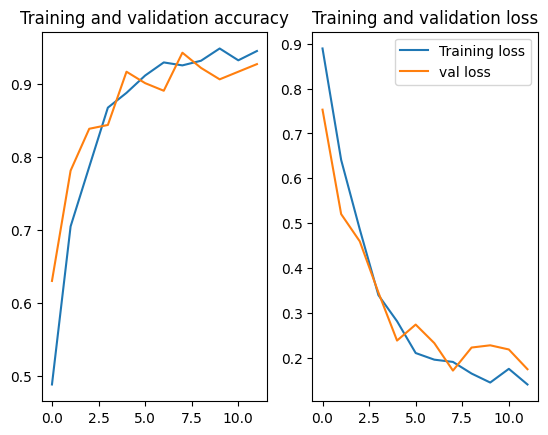

In [195]:
# plt.figure(figsize=(8,8))
trained_epochs = len(history.history['accuracy'])  # History contains the training data
plt.subplot(1,2,1)
plt.plot(range(trained_epochs), accuracy, label = 'Training accuracy')
plt.plot(range(trained_epochs), val_accuracy, label = 'val accuracy')
plt.title('Training and validation accuracy')

plt.subplot(1,2,2)
plt.plot(range(trained_epochs), loss, label = 'Training loss')
plt.plot(range(trained_epochs), val_loss, label = 'val loss')
plt.title('Training and validation loss')
plt.legend() # it will automatically manipulate where to show the label in graph..


plt.show()

In [196]:
for image_batch , label_batch in test_ds.take(1):
  pred_label = model.predict(image_batch)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 127ms/step


#### define a function which gives accuracy on the basis of actual output and pred output

In [197]:
def predict(models, image):
  img_arr = tf.keras.preprocessing.image.img_to_array(image.numpy())
  img_arr = tf.expand_dims(img_arr, 0)  # Create a batch of 1

  pred = models.predict(img_arr)
  predicted_class = class_name[np.argmax(pred[0])]
  accuracy = round(100 * (np.max(pred[0])), 2)
  return predicted_class, accuracy


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 106ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step


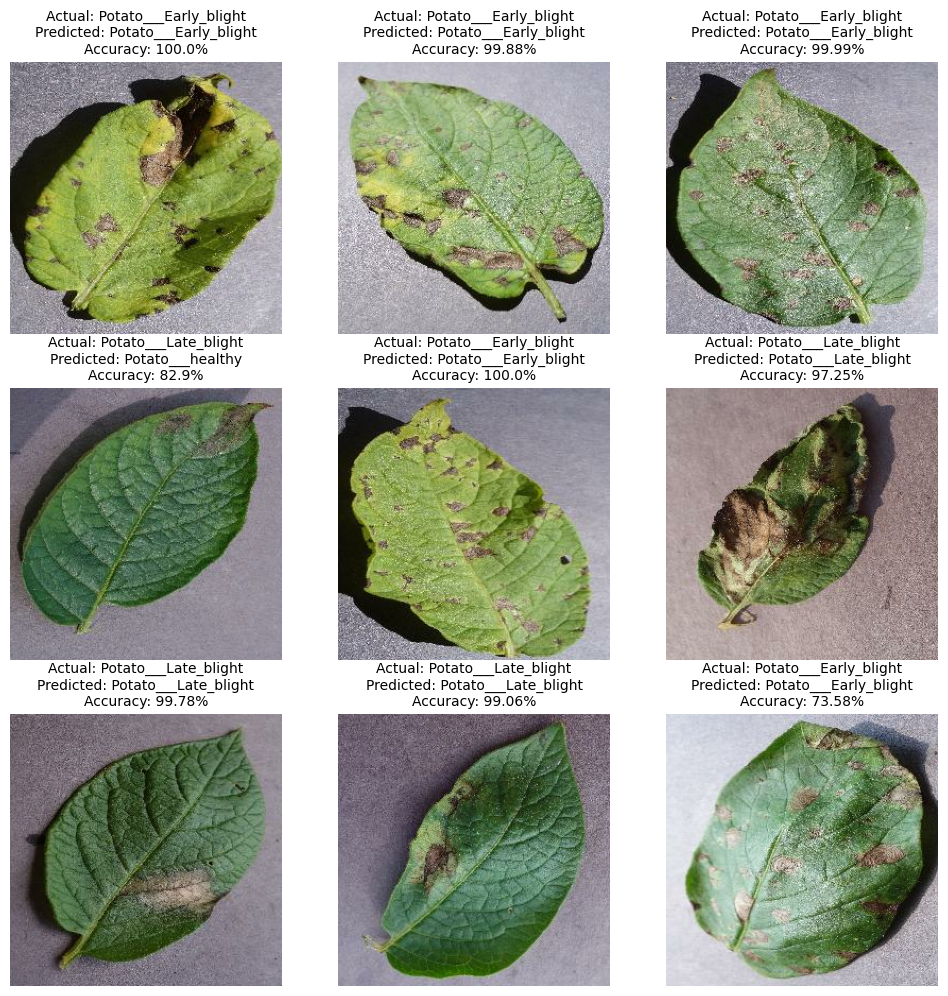

In [198]:
plt.figure(figsize=(12,12))
for image, label in test_ds.take(1):
  for i in range(9):
    plt.subplot(3,3, i+1)
    plt.imshow(image[i].numpy().astype('uint8'))
    pred, acc = predict(model, image[i])
    actual_class = class_name[label[i]]
    plt.title(f"Actual: {actual_class}\nPredicted: {pred}\nAccuracy: {acc}%", fontsize=10)  # Adjust fontsize
    plt.axis('off')

